# Case Study 
**Goal:** Fetch live weather data for 10 Indian cities, clean it, do EDA, find patterns.

In [1]:
# import 
import requests as r
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# api call to get data
api='5b147bb50f3853a73035eecb1a85357a'


In [33]:
# city list 
cities = [
    "Hyderabad", "Mumbai", "Delhi", "Chennai", "Bangalore",
    "Kolkata", "Pune", "Jaipur", "Ahmedabad", "Lucknow",
    "Surat", "Indore", "Bhopal", "Nagpur", "Patna",
    "Vadodara", "Coimbatore", "Kochi", "Visakhapatnam", "Mysore",
    "Vijayawada", "Guwahati", "Chandigarh", "Noida", "Gurgaon",
    "Agra", "Varanasi", "Amritsar", "Ranchi", "Raipur",
    "Jodhpur", "Udaipur", "Gwalior", "Madurai", "Salem",
    "Tiruchirappalli", "Thrissur", "Mangalore", "Shillong", "Dehradun",
    "Shimla", "Haridwar", "Jamshedpur", "Srinagar", "Jammu",
    "Allahabad", "Bareilly", "Moradabad", "Aligarh", "Ajmer"
]

# empty weather data 
weather_data=[]

In [34]:
# loop through each city
for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api}&units=metric"
    
    response = r.get(url)
    data = response.json()

    # extract required fields
    city_weather = {
        "City": data["name"],
        "Temperature": data["main"]["temp"],
        "Feels Like": data["main"]["feels_like"],
        "Humidity": data["main"]["humidity"],
        "Pressure": data["main"]["pressure"],
        "Visibility": data["visibility"],
        "Wind Speed": data["wind"]["speed"],
        "Weather Description": data["weather"][0]["description"]
    }

    # append into list
    weather_data.append(city_weather)

In [35]:
# convert to data frame 
df=pd.DataFrame(weather_data)
print(df.head())
print(df.shape)

        City  Temperature  Feels Like  Humidity  Pressure  Visibility  \
0  Hyderabad        31.79       31.65        38      1006       10000   
1     Mumbai        30.95       36.31        66      1010       10000   
2      Delhi        32.18       32.02        37      1004       10000   
3    Chennai        31.76       38.76        69      1006       10000   
4  Bengaluru        27.97       29.98        65      1011       10000   

   Wind Speed Weather Description  
0        3.12     overcast clouds  
1        5.81       broken clouds  
2        6.76     overcast clouds  
3        0.45     overcast clouds  
4        3.76     overcast clouds  
(50, 8)


In [36]:
# info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City                 50 non-null     str    
 1   Temperature          50 non-null     float64
 2   Feels Like           50 non-null     float64
 3   Humidity             50 non-null     int64  
 4   Pressure             50 non-null     int64  
 5   Visibility           50 non-null     int64  
 6   Wind Speed           50 non-null     float64
 7   Weather Description  50 non-null     str    
dtypes: float64(3), int64(3), str(2)
memory usage: 4.2 KB


In [37]:
# describe 
df.describe()

,Temperature,Feels Like,Humidity,Pressure,Visibility,Wind Speed
count,50.000000,50.000000,50.000000,50.000000,50.0,50.000000
mean,30.356800,31.495200,51.380000,1005.640000,10000.0,4.417200
std,4.633524,4.980239,20.984824,3.391225,0.0,2.336704
min,16.790000,15.950000,20.000000,1000.000000,10000.0,0.450000
25%,28.142500,30.097500,37.000000,1003.000000,10000.0,2.632500
50%,31.625000,32.410000,46.000000,1005.000000,10000.0,4.300000
75%,32.817500,34.800000,66.750000,1008.750000,10000.0,6.097500
max,37.590000,38.760000,95.000000,1011.000000,10000.0,8.860000


In [38]:
# check for null values 
df.isnull().sum()

City                   0
Temperature            0
Feels Like             0
Humidity               0
Pressure               0
Visibility             0
Wind Speed             0
Weather Description    0
dtype: int64

In [39]:
# check duplicates
df.duplicated().sum()

0

In [40]:
# EDA 

# max temperature
max_temp=df['Temperature'].max()
print("Maximum Temperature:",max_temp)

Maximum Temperature: 37.59


In [41]:
# minimum temperature
print("Minimum Temperature:",df['Temperature'].min())

Minimum Temperature: 16.79


In [42]:
# average temperature
print("Average Temperature:",df['Temperature'].mean())

Average Temperature: 30.3568


In [43]:
df

,City,Temperature,Feels Like,Humidity,Pressure,Visibility,Wind Speed,Weather Description
0,Hyderabad,31.79,31.65,38,1006,10000,3.12,overcast clouds
1,Mumbai,30.95,36.31,66,1010,10000,5.81,broken clouds
2,Delhi,32.18,32.02,37,1004,10000,6.76,overcast clouds
3,Chennai,31.76,38.76,69,1006,10000,0.45,overcast clouds
4,Bengaluru,27.97,29.98,65,1011,10000,3.76,overcast clouds
5,Kolkata,30.48,36.79,72,1004,10000,6.43,scattered clouds
6,Pune,28.56,28.26,41,1011,10000,4.73,scattered clouds
7,Jaipur,26.90,27.89,59,1006,10000,8.82,scattered clouds
8,Ahmedabad,32.03,34.42,50,1006,10000,7.48,clear sky
9,Lucknow,36.98,35.37,20,1001,10000,3.23,clear sky


In [44]:
# city with highest temperature 
hottest_city = df.loc[df["Temperature"].idxmax(), "City"]
print("Hottest city:", hottest_city)

Hottest city: Allahabad


In [45]:
# city with lowest temperature 
coldest_city =df.loc[df['Temperature'].idxmin(),"City"]
print("Coldest City:",coldest_city)


Coldest City: Srinagar


In [46]:
# top 3 hottest cities 
df[['City','Temperature']].sort_values('Temperature',ascending=False).head(3)

,City,Temperature
45,Allahabad,37.59
26,Varanasi,37.48
9,Lucknow,36.98


In [47]:
# top 3 coldest cities 
df[['City','Temperature']].sort_values('Temperature').head(3)

,City,Temperature
43,Srinagar,16.79
40,Shimla,16.92
38,Shillong,17.73


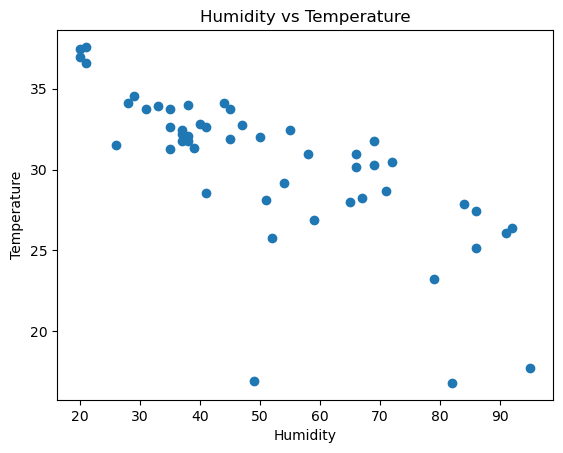

<Axes: xlabel='Humidity', ylabel='Temperature'>

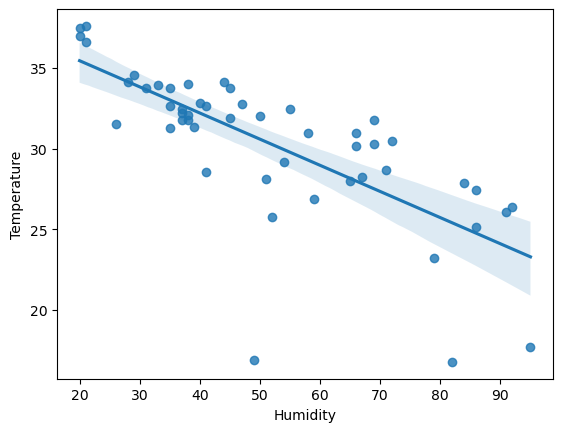

In [63]:
plt.scatter(df['Humidity'],df['Temperature'])
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Humidity vs Temperature")
plt.show()

sns.regplot(data=df,x='Humidity',y='Temperature')

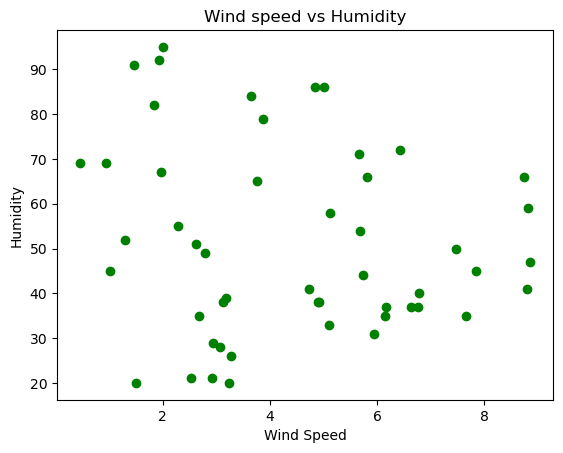

<Axes: xlabel='Wind Speed', ylabel='Humidity'>

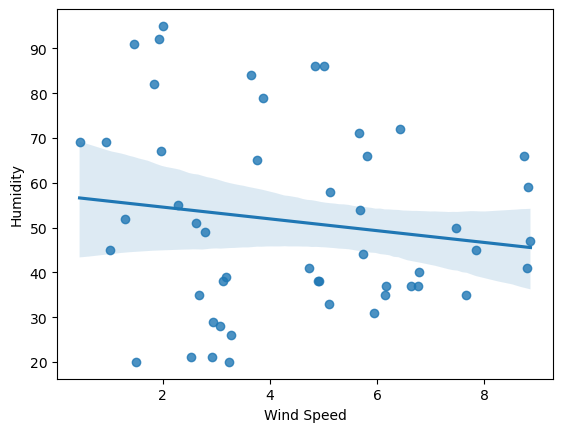

In [62]:
# does the wind speed effect the humidity ?
plt.scatter(df['Wind Speed'],df['Humidity'],marker='o',color='green')
plt.xlabel("Wind Speed")
plt.ylabel("Humidity")
plt.title("Wind speed vs Humidity")
plt.show()

sns.regplot(data=df,x='Wind Speed',y='Humidity')

<Axes: xlabel='Wind Speed', ylabel='Pressure'>

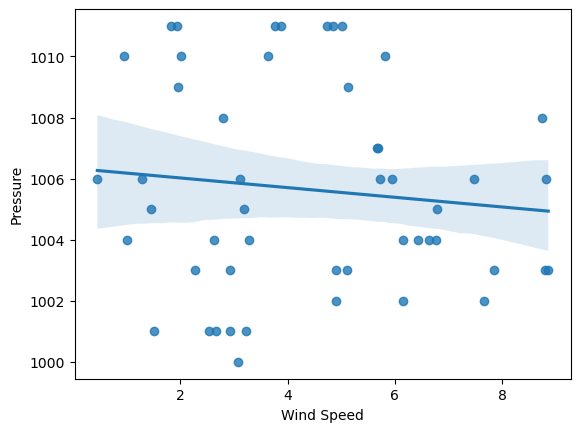

In [61]:
# wind speed and pressure 
sns.regplot(data=df,x='Wind Speed',y='Pressure')

In [52]:
df['Weather Description'].value_counts()

Weather Description
overcast clouds     16
clear sky           16
scattered clouds     8
broken clouds        7
few clouds           3
Name: count, dtype: int64

In [53]:
df.groupby('Weather Description')['Temperature'].median()

Weather Description
broken clouds       30.950
clear sky           32.795
few clouds          31.280
overcast clouds     31.170
scattered clouds    28.340
Name: Temperature, dtype: float64

In [54]:
df.columns

Index(['City', 'Temperature', 'Feels Like', 'Humidity', 'Pressure',
       'Visibility', 'Wind Speed', 'Weather Description'],
      dtype='str')

In [59]:
# correlation of the numeric columns 
num_cols=df.drop(columns=['City','Weather Description','Visibility'])

corr_matrix = num_cols.corr()
corr_matrix

,Temperature,Feels Like,Humidity,Pressure,Wind Speed
Temperature,1.000000,0.899723,-0.733222,-0.707651,0.196502
Feels Like,0.899723,1.000000,-0.441602,-0.483159,0.222919
Humidity,-0.733222,-0.441602,1.000000,0.784858,-0.146586
Pressure,-0.707651,-0.483159,0.784858,1.000000,-0.109043
Wind Speed,0.196502,0.222919,-0.146586,-0.109043,1.000000


<Axes: >

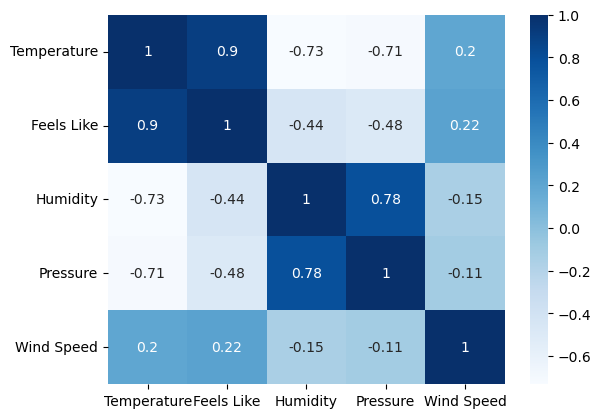

In [60]:
sns.heatmap(corr_matrix,annot=True,cmap='Blues')

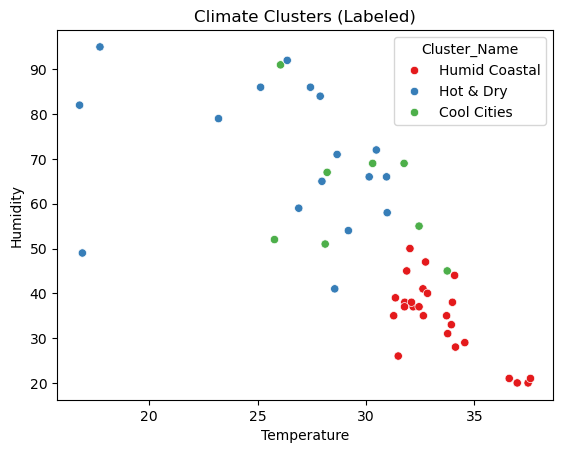

In [81]:
# clustering the cities

# 1. select features
features = df[['Temperature','Humidity','Wind Speed','Pressure']]

# 2. standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# clustering using Kmeans
from sklearn.cluster import KMeans 
k=KMeans(n_clusters=3,random_state=42)


# visualize the cluster 
df['Cluster_Name'] = df['Cluster'].map({
    0: "Hot & Dry",
    1: "Humid Coastal",
    2: "Cool Cities"
})

sns.scatterplot(
    data=df,
    x='Temperature',
    y='Humidity',
    hue='Cluster_Name',
    palette='Set1'
)

plt.title("Climate Clusters (Labeled)")
plt.show()

In [86]:
# coastal vs inland analysis 

# label the cities
coastal_cities = [
    "Mumbai","Chennai","Kochi","Visakhapatnam",
    "Mangalore","Kolkata","Surat","Pune"
]

df['Region'] = df['City'].apply(lambda x: 'Coastal' if x in coastal_cities else 'Inland')
print(df['Region'].value_counts())

Region
Inland     42
Coastal     8
Name: count, dtype: int64


In [87]:
# compare averages 
df.groupby('Region')[['Temperature','Humidity','Wind Speed']].mean()

,Temperature,Humidity,Wind Speed
Region,,,
Coastal,29.487500,69.375000,5.037500
Inland,30.522381,47.952381,4.299048


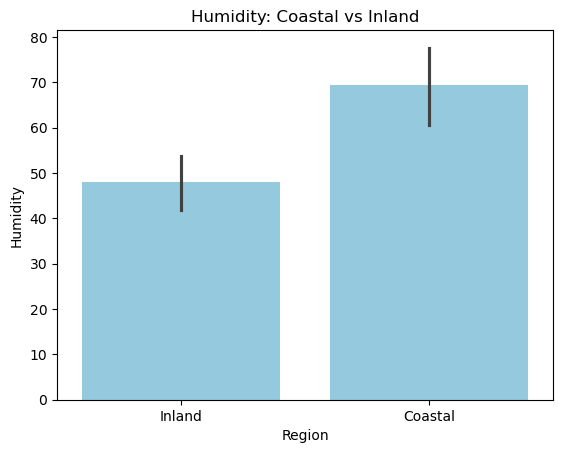

In [89]:
sns.barplot(data=df, x='Region', y='Humidity',color='skyblue')
plt.title("Humidity: Coastal vs Inland")
plt.show()

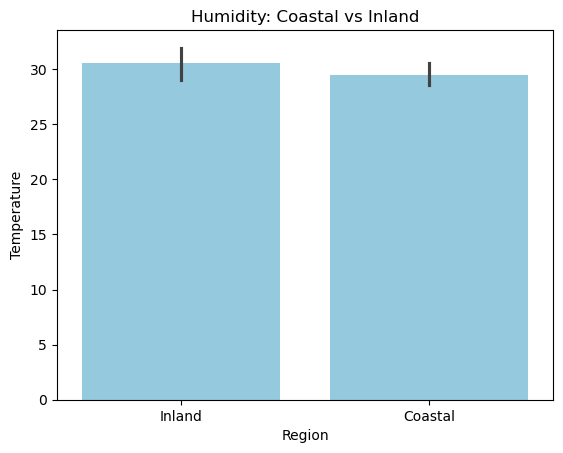

In [90]:
sns.barplot(data=df, x='Region', y='Temperature',color='skyblue')
plt.title("Humidity: Coastal vs Inland")
plt.show()

In [91]:
# save dataset 
df.to_csv("weather_api_eda.csv", index=False)